# AI-Powered Meta-Software Development System
## DTS114TC Coursework — Task 1

### Business Problem
This notebook automatically generates a complete software system for an **Online Bookstore**.
The bookstore allows customers to browse books, search by genre or author, and view book details.

### What This Notebook Generates
| Output | Location |
|--------|----------|
| Flask API (`app.py`) | `app/app.py` |
| Website frontend (`index.html`) | `app/templates/index.html` |
| AI-generated banner image | `app/static/images/generated.png` |
| UML diagrams (class + sequence) | `docs/uml/` |
| SDLC requirements document | `docs/requirements.md` |

### Tools & Libraries Used
- **OpenAI-compatible LLM** (via APIFree) — code and documentation generation
- **DALL·E** — AI image generation
- **Flask** — web framework for the generated API
- **PlantUML** (online renderer) — UML diagram generation
- **python-dotenv / os.environ** — secure credential management

---
## Section 1 — Environment Setup & LLM Connectivity Test

In [30]:
# Install any missing packages
import subprocess, sys
packages = ['openai', 'flask', 'requests', 'pillow', 'python-dotenv']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [31]:
import os
import json
import requests
from pathlib import Path
from dotenv import load_dotenv
from openai import OpenAI

ROOT_DIR = Path.cwd().resolve().parent
load_dotenv(ROOT_DIR / '.env')

# Support both the classroom APIFree naming and the OpenAI-style naming.
API_KEY = os.environ.get('APIFREE_API_KEY') or os.environ.get('OPENAI_API_KEY', '')
BASE_URL = os.environ.get('OPENAI_BASE_URL', 'https://api.apifree.ai/v1')
MODEL = os.environ.get('OPENAI_MODEL') or os.environ.get('APIFREE_MODEL') or 'openai/gpt-5.2'

assert API_KEY, 'ERROR: Set APIFREE_API_KEY or OPENAI_API_KEY in the .env file.'

client = OpenAI(api_key=API_KEY, base_url=BASE_URL)
print(f'Client created. Model: {MODEL}  |  Base URL: {BASE_URL}')

Client created. Model: openai/gpt-5.2  |  Base URL: https://api.apifree.ai/v1


In [32]:
# --- LLM connectivity test ---
def call_llm(prompt: str, system: str = 'You are a senior software engineer.') -> str:
    """Helper: send a prompt to the LLM and return the response text."""
    response = client.chat.completions.create(
        model=MODEL,
        messages=[
            {'role': 'system', 'content': system},
            {'role': 'user',   'content': prompt}
        ],
        temperature=0.3
    )
    return response.choices[0].message.content

test = call_llm('Reply with exactly: LLM connection successful.')
print(test)

LLM connection successful.


In [33]:
# --- Output directory setup ---
BASE_DIR = Path('.')  # notebook is in Task1/
DIRS = [
    BASE_DIR / 'app' / 'templates',
    BASE_DIR / 'app' / 'static' / 'images',
    BASE_DIR / 'docs' / 'uml',
]
for d in DIRS:
    d.mkdir(parents=True, exist_ok=True)
print('Output directories confirmed.')

Output directories confirmed.


---
## Section 2 — Inception Phase (AI-Driven SDLC)

Following the AI-Driven Development Lifecycle Methodology from the lab sessions:
business intent is converted into execution-ready context through four chain-linked LLM steps.

1. **Problem Statement** — refine the business problem into a concise statement  
2. **Personas** — identify stakeholders and their needs  
3. **PRD** — produce a structured Product Requirements Document  
4. **User Stories** — extract actionable user stories from the PRD

In [34]:
# ── Step 1: Define the business problem (edit this string to change the domain) ──
business_problem = (
    "An online bookstore needs a catalogue website that lets customers browse, "
    "search, and filter books by genre or author, and provides a REST API for "
    "programmatic access to the book inventory."
)

print("Business problem defined.")

Business problem defined.


In [35]:
# ── Step 2: Generate Problem Statement ──
print("--- Generating Problem Statement ---")
problem_statement = call_llm(
    f"Given the business problem below, generate one clear and concise problem statement.\n"
    f"Business Problem: {business_problem}",
)
print(problem_statement)

--- Generating Problem Statement ---
Design and implement an online bookstore catalogue website and REST API that allow customers and external clients to browse, search, and filter the book inventory by genre and author.


In [36]:
# ── Step 3: Generate Personas ──
print("--- Generating Personas ---")
personas = call_llm(
    "Generate 2-4 user personas for the solution using this format:\n"
    "Personas: <one-sentence intro>\n\n"
    "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
    "Rules: Use single role titles only; no slashes (/) or combined titles. "
    "Keep each bullet concise.\n"
    f"Problem Statement: {problem_statement}"
)
print(personas)

--- Generating Personas ---
Personas: Key users span end customers browsing the catalogue, internal staff maintaining inventory metadata, and external developers integrating via the REST API.

1. **Customer**
   - **Responsibilities:** Browse the catalogue; search and filter by genre/author; view book details.
   - **Needs:** Fast search; clear filters; accurate availability and descriptions; mobile-friendly pages.

2. **Librarian**
   - **Responsibilities:** Add and update book records; manage genres/authors metadata; correct catalogue errors.
   - **Needs:** Simple admin workflows; validation to prevent duplicates; bulk edit/import; audit history.

3. **Developer**
   - **Responsibilities:** Integrate the REST API into partner apps; implement search and filtering features; monitor API usage.
   - **Needs:** Well-documented endpoints; stable schemas and versioning; pagination and filtering parameters; predictable error responses.


In [37]:
# ── Step 4: Generate PRD ──
import re as _re

print("--- Generating PRD ---")
prd_raw = call_llm(
    "Write a PRD in markdown with these headings, each with 2-4 concise bullets:\n"
    "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
    "## Key Features\n## User Flows\n## Functional Requirements\n"
    "## Non-Functional Requirements\n## Constraints/Assumptions\n"
    "## Success Metrics\n## Open Questions\n\n"
    "Rules: Use only the headings above. No extra sections. Keep bullets short.\n"
    f"Problem Statement: {problem_statement}\n"
    f"Personas: {personas}"
)
# Strip code fences if present
prd = _re.sub(r'^```(?:markdown)?\s*', '', prd_raw.strip(), flags=_re.IGNORECASE)
prd = _re.sub(r'```\s*$', '', prd.strip())

print(prd[:600], '\n... [truncated]')

--- Generating PRD ---
## Overview
- Public web catalogue + REST API for browsing and querying books
- Search and filter inventory by genre and author
- Supports customer discovery, staff metadata maintenance, and partner integrations

## Goals
- Enable fast browse/search/filter of books by genre/author on web and API
- Provide accurate book detail pages (metadata + availability)
- Provide secure, documented, versioned REST API for external clients
- Allow staff to create/update books, authors, and genres reliably

## Non-Goals
- Checkout, payments, shipping, or order management
- User accounts, reviews/ratings, or  
... [truncated]


In [38]:
# ── Step 5: Generate User Stories (JSON) ──
import json as _json

print("--- Generating User Stories ---")
stories_raw = call_llm(
    "Return ONLY valid JSON with this schema:\n"
    '{\n  "user_stories": [\n    {\n      "id": 1,\n      "role": "<role>",\n'
    '      "goal": "<goal>",\n      "benefit": "<benefit>",\n'
    '      "acceptance_criteria": ["<criteria>", "<criteria>"]\n    }\n  ]\n}\n\n'
    "Rules: Provide 5 stories. Keep each field concise. No extra keys.\n"
    f"PRD: {prd}"
)
# Strip code fences
stories_raw = _re.sub(r'^```(?:json)?\s*', '', stories_raw.strip(), flags=_re.IGNORECASE)
stories_raw = _re.sub(r'```\s*$', '', stories_raw.strip())

try:
    user_stories_data = _json.loads(stories_raw)
    user_stories = user_stories_data.get('user_stories', [])
    print(f"Generated {len(user_stories)} user stories.")
    for s in user_stories:
        print(f"  [{s['id']}] As a {s['role']}, I want to {s['goal']}")
except Exception as e:
    print(f"JSON parse error: {e}\nRaw output:\n{stories_raw[:300]}")
    user_stories = []

--- Generating User Stories ---
Generated 5 user stories.
  [1] As a Customer, I want to Search books by title or author and filter by genres/authors
  [2] As a Customer, I want to View a book detail page
  [3] As a Developer, I want to Query books via a versioned REST API with filters and pagination
  [4] As a Developer, I want to Access API securely using an API key with rate limits
  [5] As a Librarian, I want to Create/update/deactivate books, authors, and genres with duplicate checks


---
## Section 2 — Generate Flask API (`app.py`)

In [39]:
FLASK_PROMPT = f"""
You are a senior Python developer. Based on the Product Requirements Document (PRD) below,
generate a complete, production-ready Flask REST API application.

PRD:
{prd}

Hard requirements (always apply regardless of PRD):
- File: app.py
- Use Flask and flask-cors
- In-memory data store (a Python list of dicts, no database)
- Pre-populate with at least 6 realistic sample data items relevant to the PRD
- Each item must have: id, name/title, category/genre, price, description
- API endpoints:
    GET  /api/items          — list all items (supports optional ?category= and ?search= query params)
    GET  /api/items/<int:id> — get a single item by id
    POST /api/items          — add a new item (JSON body)
    GET  /api/categories     — list all unique categories
    GET  /                   — serve index.html from templates/
- Include proper error handling (404 for not found, 400 for bad input)
- Add CORS support via flask-cors
- Return ONLY the raw Python code with no markdown fences or explanation.
"""

print('Generating Flask API code from PRD...')
flask_code = call_llm(FLASK_PROMPT)
print(flask_code[:500], '\n... [truncated for display]')

Generating Flask API code from PRD...
from flask import Flask, jsonify, request, render_template
from flask_cors import CORS
from werkzeug.exceptions import HTTPException
from datetime import datetime, timezone
import threading
import time
import secrets

app = Flask(__name__, template_folder="templates")
CORS(app)

# -----------------------------
# In-memory datastore
# -----------------------------
_DATA_LOCK = threading.Lock()
_ITEMS = [
    {
        "id": 1,
        "title": "The Pragmatic Programmer",
        "genre": "Softwar 
... [truncated for display]


In [40]:
# Write generated Flask app to file
app_path = BASE_DIR / 'app' / 'app.py'
app_path.write_text(flask_code, encoding='utf-8')
print(f'Flask API written to: {app_path.resolve()}')

Flask API written to: D:\dts114\Task1\app\app.py


In [41]:
# ── Auto-generate requirements.txt from app.py imports ──
print("--- Generating requirements.txt ---")

_app_py = BASE_DIR / 'app' / 'app.py'

# If the file hasn't been written yet, write it now
if not _app_py.exists():
    _app_py.parent.mkdir(parents=True, exist_ok=True)
    _app_py.write_text(flask_code, encoding='utf-8')

app_code = _app_py.read_text(encoding='utf-8')

# Extract only import lines from the top of the file
import_lines = []
for line in app_code.split('\n'):
    stripped = line.strip()
    if stripped.startswith('import ') or stripped.startswith('from '):
        import_lines.append(stripped)
    elif stripped and not stripped.startswith('#'):
        break  # stop at first non-import, non-comment line

imports_text = '\n'.join(import_lines)
print(f"  Found {len(import_lines)} import statement(s)")

req_raw = call_llm(
    f"Based on these Python import statements, list all required third-party package names "
    f"(one per line, no version constraints, no standard library modules, no duplicates).\n"
    f"Import statements:\n{imports_text}"
)
req_lines = sorted({l.strip() for l in req_raw.strip().splitlines() if l.strip() and not l.strip().startswith('#')})
# Always ensure gunicorn is included for deployment
if 'gunicorn' not in req_lines:
    req_lines.append('gunicorn')
req_text = '\n'.join(sorted(req_lines)) + '\n'

req_path_txt = BASE_DIR / 'app' / 'requirements.txt'
req_path_txt.write_text(req_text, encoding='utf-8')
print(f"requirements.txt written: {req_lines}")

--- Generating requirements.txt ---
  Found 7 import statement(s)
requirements.txt written: ['flask', 'flask-cors', 'werkzeug', 'gunicorn']


---
## Section 3 — Generate Website Frontend (`index.html`)

In [42]:
HTML_PROMPT = f"""
You are a senior front-end developer. Based on the Product Requirements Document (PRD) below,
generate a complete, single-file HTML website that serves as the front end for the Flask API
already built.

PRD:
{prd}

Hard requirements (always apply):
- Modern design using Bootstrap 5 (CDN)
- Navbar with the application name derived from the PRD
- Hero banner section that displays an AI-generated image from: /static/images/generated.png
- Catalogue/listing section: fetch items from /api/items using JavaScript fetch()
  and render them as Bootstrap cards (show name/title, category, price, description)
- Search bar that filters items by calling /api/items?search=<term>
- Category filter dropdown populated from /api/categories
- Footer with copyright
- All JavaScript inline (no external JS files)
- Return ONLY the raw HTML code with no markdown fences or explanation.
"""

print('Generating website HTML from PRD...')
html_code = call_llm(HTML_PROMPT)
print(html_code[:500], '\n... [truncated for display]')

Generating website HTML from PRD...
<!doctype html>
<html lang="en">
<head>
  <meta charset="utf-8" />
  <meta name="viewport" content="width=device-width, initial-scale=1" />
  <title>Book Catalogue & API</title>
  <meta name="description" content="Public web catalogue + REST API for browsing and querying books." />

  <!-- Bootstrap 5 CDN -->
  <link href="https://cdn.jsdelivr.net/npm/bootstrap@5.3.3/dist/css/bootstrap.min.css" rel="stylesheet" integrity="sha384-QWTKZyjpPEjISv5WaRU9OFeRpok6YctnYmDr5pNlyT2bRjXh0JMhjY6hW+ALEwIH" c 
... [truncated for display]


In [43]:
# Write generated HTML to templates folder
html_path = BASE_DIR / 'app' / 'templates' / 'index.html'
html_path.write_text(html_code, encoding='utf-8')
print(f'Website HTML written to: {html_path.resolve()}')

Website HTML written to: D:\dts114\Task1\app\templates\index.html


---
## Section 4 — Generate AI Image (Banner / Book Cover)

Uses **Pollinations.ai** (free, no API key required) to generate a bookstore hero banner via Stable Diffusion.
Falls back to DALL·E, then to a styled matplotlib dashboard if both are unavailable.


In [56]:
import urllib.request, urllib.error, json as _json, base64 as _b64

IMAGE_PROMPT = (
    'A beautiful online bookstore hero banner illustration. '
    'Warm cozy atmosphere, shelves full of colorful books, soft lighting, '
    'digital art style, wide aspect ratio.'
)

image_path = BASE_DIR / 'app' / 'static' / 'images' / 'generated.png'

def _apifree_image(prompt, save_path, model_id):
    """Call APIFree text-to-image model via chat completions endpoint."""
    body = _json.dumps({'model': model_id, 'prompt': prompt}).encode()
    req = urllib.request.Request(
        f'{BASE_URL.rstrip("/v1")}/v1/chat/completions',
        data=body,
        headers={'Authorization': f'Bearer {API_KEY}', 'Content-Type': 'application/json'},
        method='POST'
    )
    with urllib.request.urlopen(req, timeout=60) as r:
        data = _json.loads(r.read())

    # bytedance/seedream-4.5 returns resp_data.data[].url
    resp = data.get('resp_data', data)
    items = resp.get('data', [])
    if items:
        img_url = items[0].get('url', '')
        b64 = items[0].get('b64_json', '')
        if img_url:
            urllib.request.urlretrieve(img_url, save_path)
            return
        if b64:
            save_path.write_bytes(_b64.b64decode(b64))
            return

    # google/nano-banana-2 returns base64 in resp_data.candidates[].content.parts[].inlineData.data
    for cand in resp.get('candidates', []):
        for part in cand.get('content', {}).get('parts', []):
            inline = part.get('inlineData', {})
            if inline.get('data'):
                save_path.write_bytes(_b64.b64decode(inline['data']))
                return

    raise RuntimeError(f'No image data in response: {str(data)[:200]}')

_image_source = None

# ── Attempt 1 & 2: APIFree native text-to-image models ──
for label, model_id in [
    ('APIFree Seedream-4.5 (ByteDance)', 'bytedance/seedream-4.5'),
    ('APIFree Nano-Banana-2 (Google)',   'google/nano-banana-2'),
]:
    try:
        print(f'Requesting AI image via {label}...')
        _apifree_image(IMAGE_PROMPT, image_path, model_id)
        _image_source = label
        print(f'AI image saved ({label}): {image_path.resolve()}')
        break
    except Exception as _e:
        print(f'{label} unavailable: {_e}')

# ── Attempt 3: DALL·E via OpenAI client ──
if _image_source is None:
    try:
        print('Trying DALL·E...')
        img_response = client.images.generate(
            model='dall-e-3', prompt=IMAGE_PROMPT, n=1, size='1024x1024'
        )
        urllib.request.urlretrieve(img_response.data[0].url, image_path)
        _image_source = 'DALL·E 3'
        print(f'DALL·E image saved: {image_path.resolve()}')
    except Exception as _e:
        print(f'DALL·E unavailable: {_e}')
        print('→ Will use matplotlib fallback in next cell.')
        _image_source = 'matplotlib (fallback)'


Requesting AI image via APIFree Seedream-4.5 (ByteDance)...
AI image saved (APIFree Seedream-4.5 (ByteDance)): D:\dts114\Task1\app\static\images\generated.png


Image source: APIFree Seedream-4.5 (ByteDance)


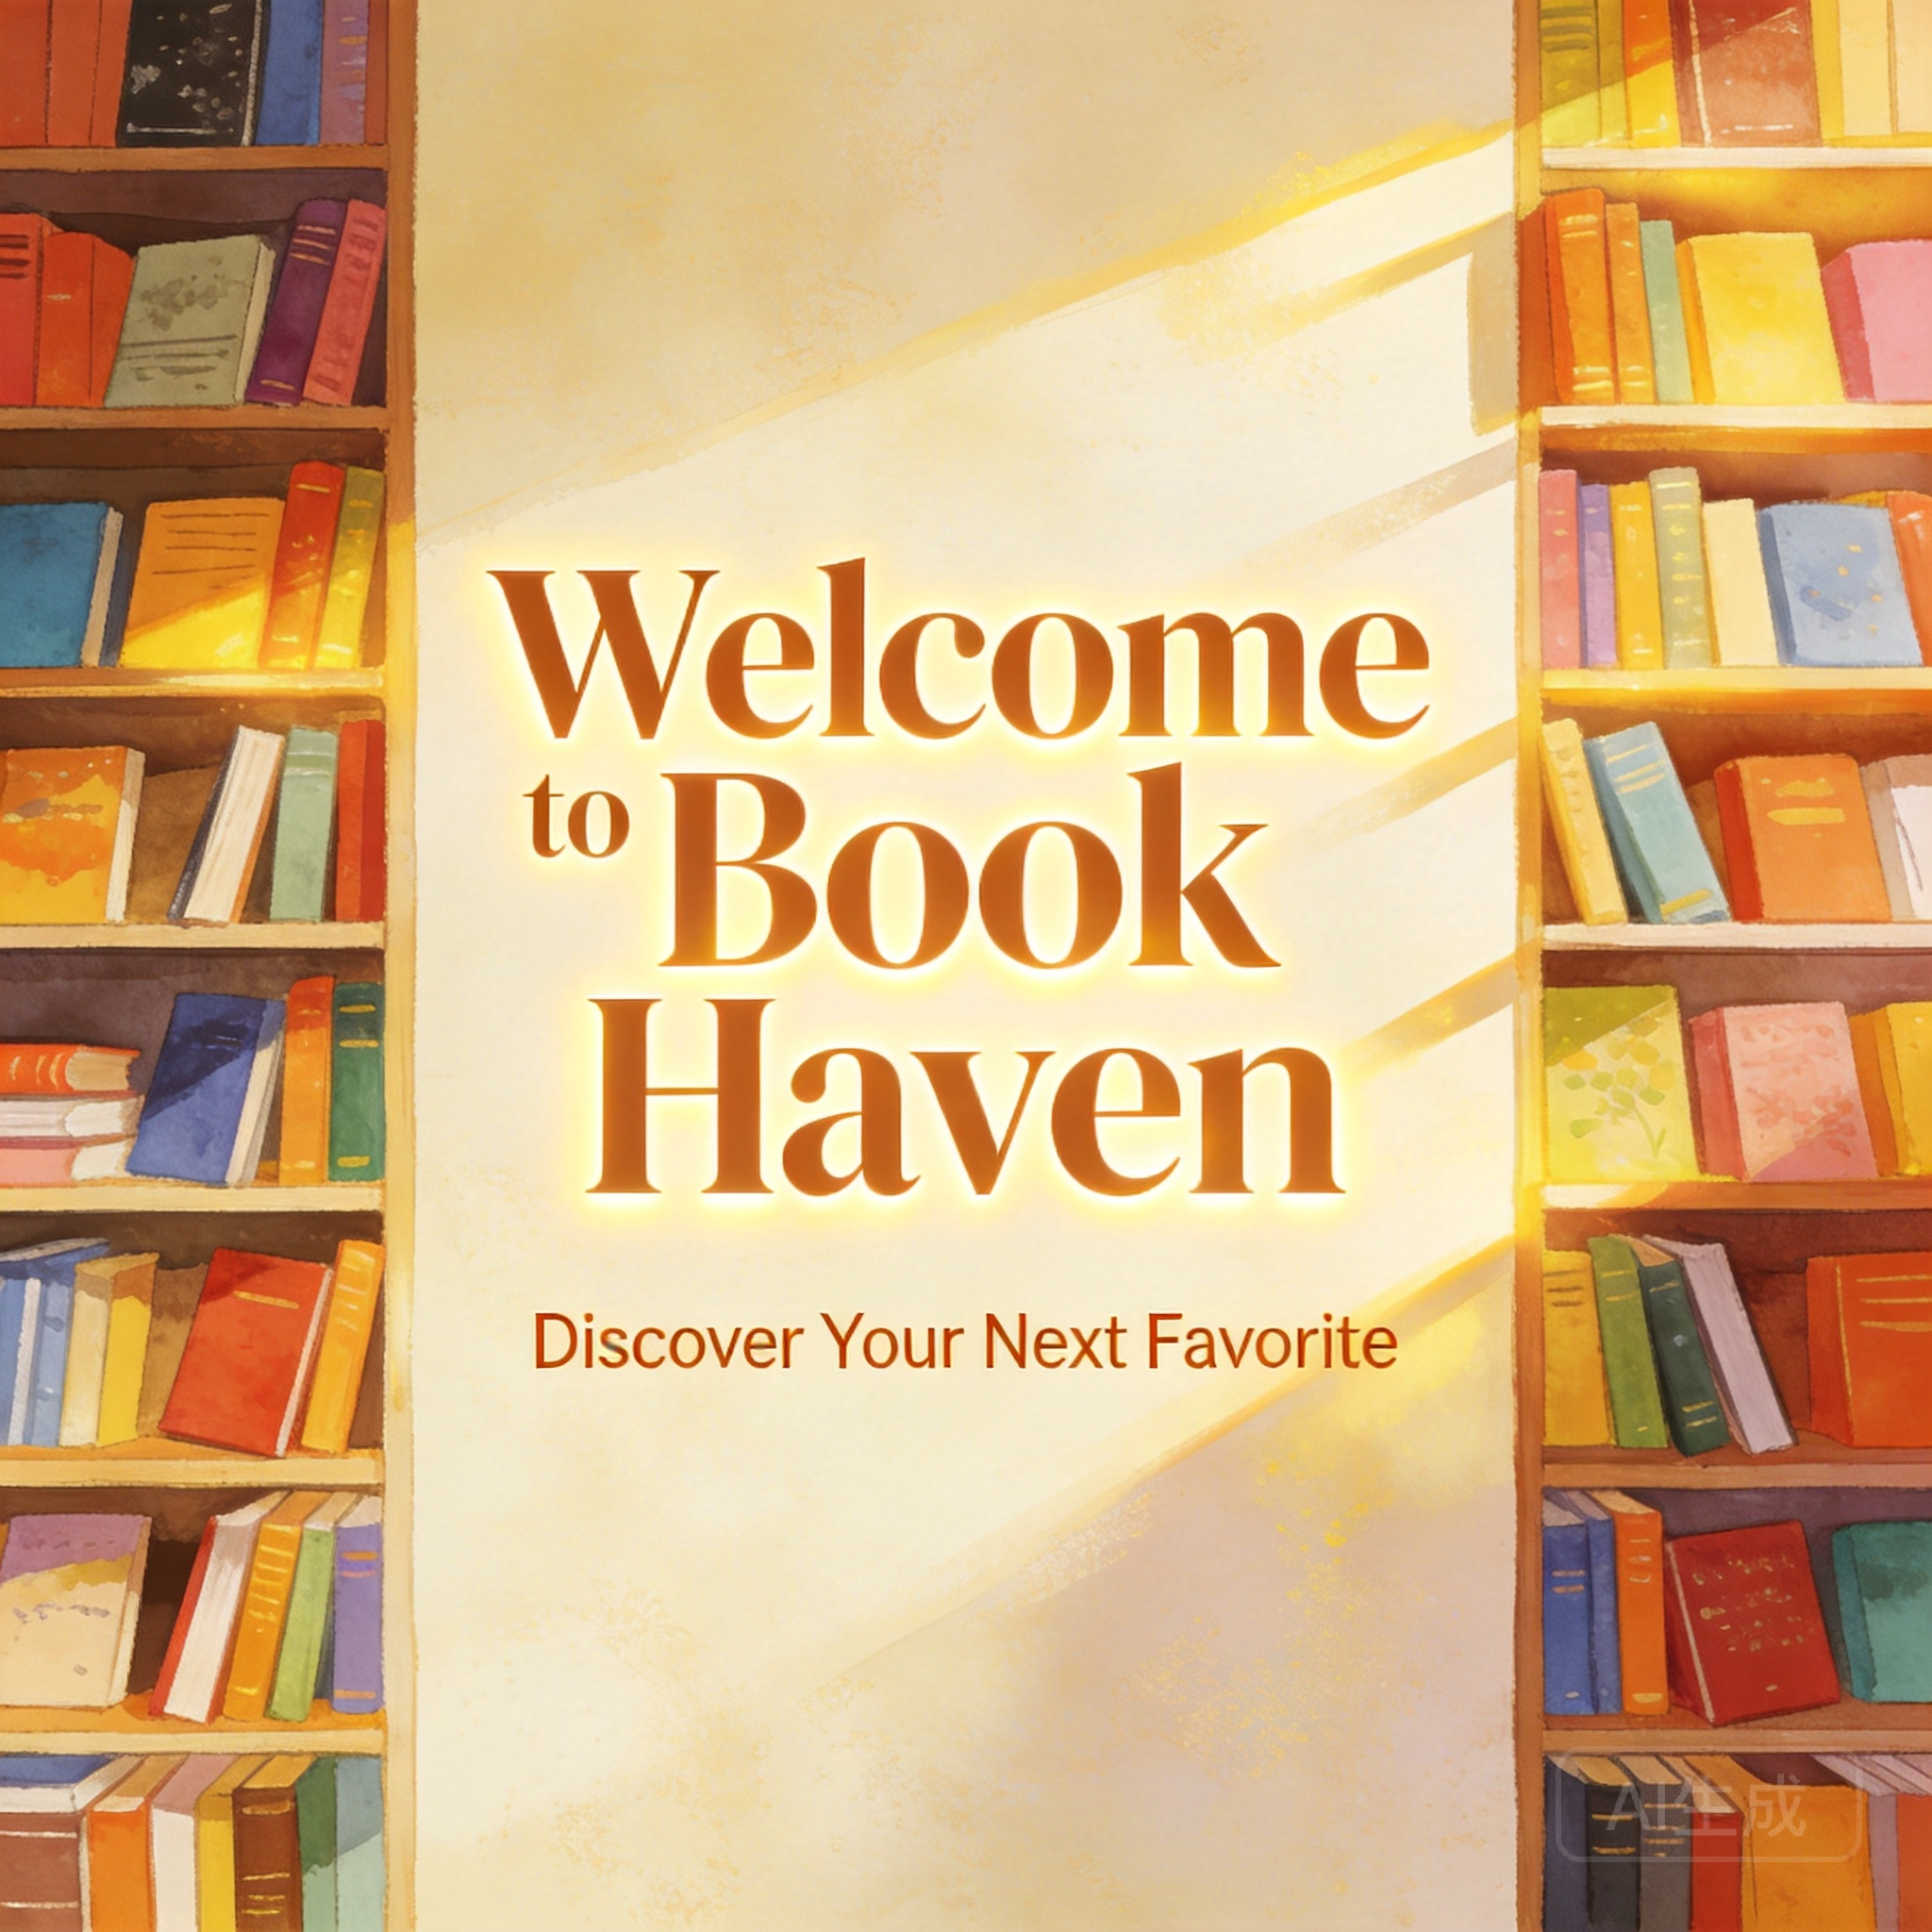

In [58]:
# ── Display the AI-generated image in the notebook ──
from IPython.display import Image, display

print(f'Image source: {_image_source}')
display(Image(filename=str(image_path), width=750))


---
## Section 5 — Generate UML Diagrams

Uses LLM to produce PlantUML source code, then renders diagrams via the public PlantUML server.

In [48]:
import zlib
import requests as _req

def _encode6bit(value: int) -> str:
    if value < 10: return chr(48 + value)
    value -= 10
    if value < 26: return chr(65 + value)
    value -= 26
    if value < 26: return chr(97 + value)
    value -= 26
    return '-' if value == 0 else '_'

def _append3bytes(b1: int, b2: int, b3: int) -> str:
    return ''.join(_encode6bit(c) for c in (
        b1 >> 2,
        ((b1 & 0x3) << 4) | (b2 >> 4),
        ((b2 & 0xF) << 2) | (b3 >> 6),
        b3 & 0x3F
    ))

def _encode_plantuml(text: str) -> str:
    compressed = zlib.compress(text.encode('utf-8'))[2:-4]
    parts = []
    for i in range(0, len(compressed), 3):
        b1 = compressed[i]
        b2 = compressed[i + 1] if i + 1 < len(compressed) else 0
        b3 = compressed[i + 2] if i + 2 < len(compressed) else 0
        parts.append(_append3bytes(b1, b2, b3))
    return ''.join(parts)

def render_plantuml(puml_text: str, filename: str):
    """Render PlantUML source to PNG using the public PlantUML server."""
    encoded = _encode_plantuml(puml_text)
    url = f'https://www.plantuml.com/plantuml/png/{encoded}'
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
    resp = _req.get(url, headers=headers, timeout=30)
    resp.raise_for_status()
    out_path = BASE_DIR / 'docs' / 'uml' / filename
    out_path.write_bytes(resp.content)
    print(f'UML diagram saved: {out_path.resolve()} ({len(resp.content)} bytes)')
    return out_path

print('render_plantuml helper defined.')

render_plantuml helper defined.


In [49]:
import json as _json
import re as _re

# Derive system name from business_problem for use in prompts
_system_name = call_llm(
    f"In 3-5 words, give a short name for this system (no explanation, just the name):\n{business_problem}"
).strip().strip('"')
print(f"System name: {_system_name}")

# ── Use Case Diagram (from user stories generated in Inception Phase) ──
USE_CASE_PROMPT = (
    "Generate a UML-compliant PlantUML use case diagram based on the user stories below.\n"
    "Required structure:\n"
    "@startuml\n"
    "actor ActorName\n"
    f"rectangle \"{_system_name}\" {{\n"
    "  usecase \"Use Case Name\" as UC1\n"
    "}\n"
    "ActorName -- UC1\n"
    "@enduml\n\n"
    "UML Rules:\n"
    "- Actors outside the system boundary using `actor` keyword\n"
    "- Use cases inside `rectangle` using `usecase` keyword\n"
    "- Associations use `--` (not arrows)\n"
    "- Verb-noun use case names (max 5 words), no numbering\n"
    "- Use `<<include>>` for shared behaviour, `<<extend>>` for optional behaviour\n"
    "- Return ONLY valid PlantUML code, no commentary\n\n"
    f"User Stories: {_json.dumps(user_stories, indent=2) if user_stories else 'Use generic user stories based on the PRD.'}"
)

print('Generating use case diagram PlantUML...')
use_case_puml = call_llm(USE_CASE_PROMPT)
use_case_puml = _re.sub(r'^```(?:plantuml)?\s*', '', use_case_puml.strip(), flags=_re.IGNORECASE)
use_case_puml = _re.sub(r'```\s*$', '', use_case_puml.strip())

(BASE_DIR / 'docs' / 'uml' / 'use_case_diagram.puml').write_text(use_case_puml, encoding='utf-8')
print('Saved: docs/uml/use_case_diagram.puml')

System name: Book Catalogue REST Platform
Generating use case diagram PlantUML...
Saved: docs/uml/use_case_diagram.puml


UML diagram saved: D:\dts114\Task1\docs\uml\use_case_diagram.png (41308 bytes)


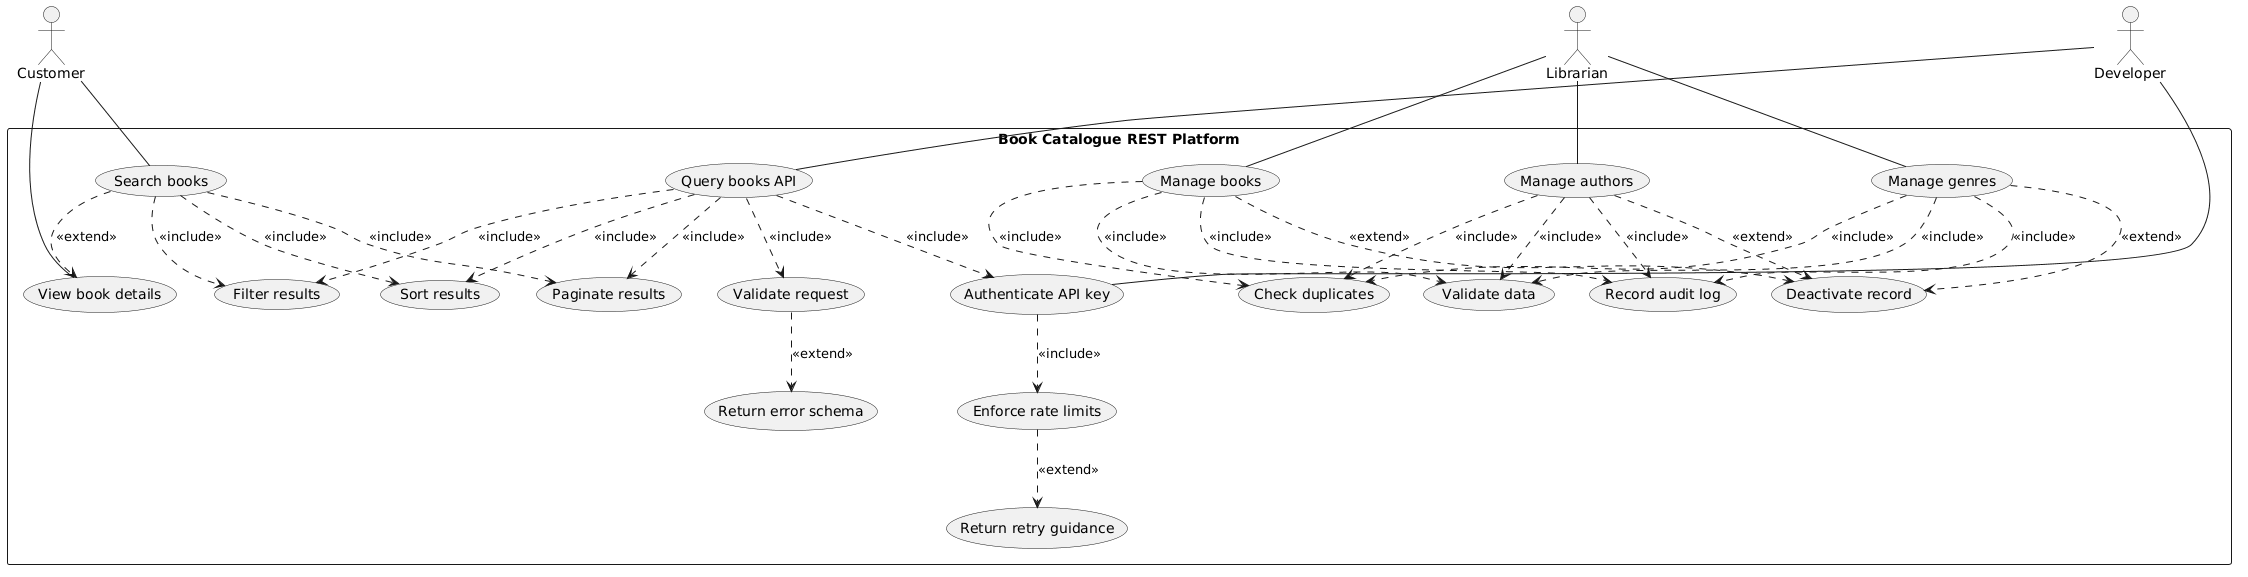

In [50]:
# Render use case diagram to PNG
# Re-read the (possibly corrected) .puml file before rendering
_puml_file = BASE_DIR / 'docs' / 'uml' / 'use_case_diagram.puml'
use_case_puml = _puml_file.read_text(encoding='utf-8')
use_case_img = render_plantuml(use_case_puml, 'use_case_diagram.png')
display(Image(filename=str(use_case_img), width=700))

Generating class diagram PlantUML...
UML diagram saved: D:\dts114\Task1\docs\uml\class_diagram.png (27524 bytes)


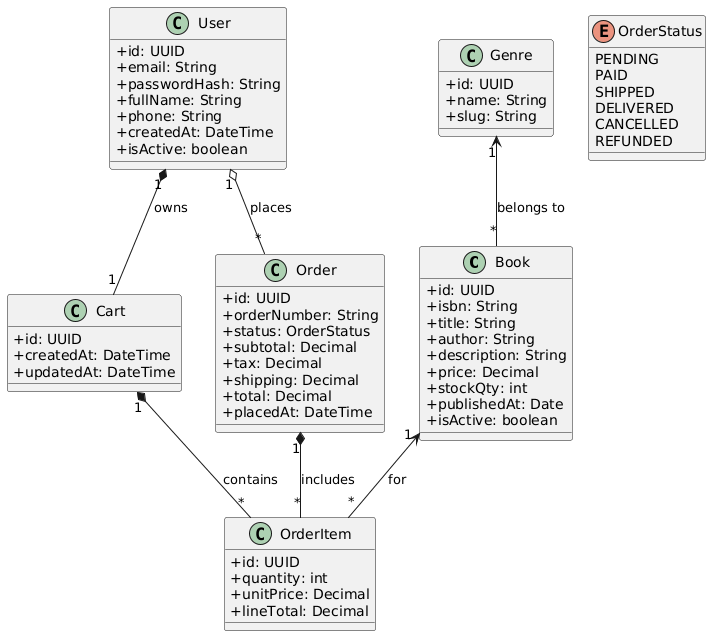

In [24]:
# --- Class Diagram ---
CLASS_PROMPT = f"""
Write a PlantUML class diagram for the system described below.

System description:
{prd}

Requirements:
- Include 5-7 relevant classes derived from the PRD
- Show realistic attributes (with types) and relationships (association, composition, inheritance)
- Return ONLY the raw PlantUML code starting with @startuml and ending with @enduml.
"""

print('Generating class diagram PlantUML...')
class_puml = call_llm(CLASS_PROMPT)

# Save source
(BASE_DIR / 'docs' / 'uml' / 'class_diagram.puml').write_text(class_puml, encoding='utf-8')

# Render to PNG
class_img = render_plantuml(class_puml, 'class_diagram.png')
display(Image(filename=str(class_img), width=700))

Generating sequence diagram PlantUML...
UML diagram saved: D:\dts114\Task1\docs\uml\sequence_diagram.png (44439 bytes)


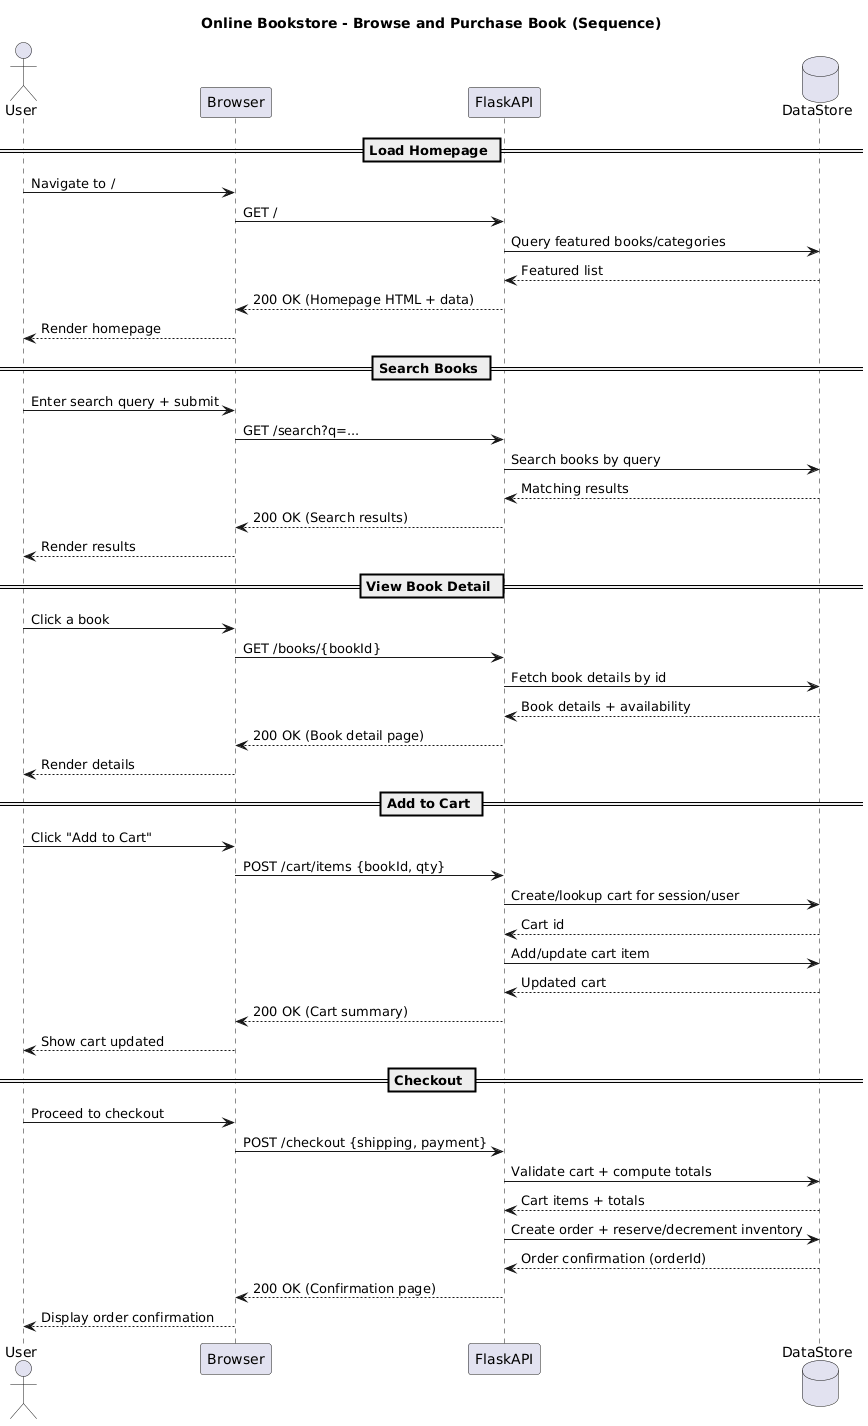

In [25]:
# --- Sequence Diagram ---
SEQ_PROMPT = f"""
Write a PlantUML sequence diagram showing a typical user workflow for the system described below.

System description:
{prd}

Requirements:
- Include 3-5 participants relevant to the system (e.g. User, Browser, FlaskAPI, DataStore)
- Cover the main happy-path flow (e.g. load page, search/browse, view detail, perform action)
- Return ONLY the raw PlantUML code starting with @startuml and ending with @enduml.
"""

print('Generating sequence diagram PlantUML...')
seq_puml = call_llm(SEQ_PROMPT)

(BASE_DIR / 'docs' / 'uml' / 'sequence_diagram.puml').write_text(seq_puml, encoding='utf-8')

seq_img = render_plantuml(seq_puml, 'sequence_diagram.png')
display(Image(filename=str(seq_img), width=700))

---
## Section 6 — Generate SDLC Documentation (Requirements)

In [26]:
# ── SDLC requirements.md — derived from the PRD generated in Inception Phase ──
# The PRD already contains key sections; here we ask the LLM to expand it into
# a full requirements document with numbered Functional / Non-Functional Requirements.

DOCS_PROMPT = (
    "You are a senior business analyst. Expand the PRD below into a professional "
    "SDLC requirements document in Markdown format.\n\n"
    "Include ALL of the following sections:\n"
    "1. Project Overview\n"
    "2. Stakeholders (derive from the personas in the PRD)\n"
    "3. Functional Requirements (at least 10, written as 'The system shall...')\n"
    "4. Non-Functional Requirements (performance, security, usability — at least 5)\n"
    "5. User Stories (at least 6, in standard format: "
    "As a <role>, I want <goal> so that <benefit>)\n"
    "6. System Constraints\n"
    "7. Assumptions\n\n"
    "Return ONLY the Markdown content with no extra commentary.\n\n"
    f"PRD:\n{prd}"
)

print('Generating SDLC requirements documentation from PRD...')
requirements_doc = call_llm(DOCS_PROMPT)
print(requirements_doc[:500], '\n... [truncated]')

Generating SDLC requirements documentation from PRD...
```markdown
# SDLC Requirements Document — Book Catalogue Web & REST API

## 1. Project Overview

### 1.1 Purpose
Deliver a web-based catalogue for browsing and viewing book details, supported by a REST API that exposes equivalent inventory discovery capabilities for third-party integrations. Provide authenticated store manager tooling to maintain catalogue data with validation and auditability.

### 1.2 Scope (In-Scope)
- Public web catalogue:
  - Browse book listings with pagination and sortin 
... [truncated]


In [27]:
# Write requirements document
req_path = BASE_DIR / 'docs' / 'requirements.md'
req_path.write_text(requirements_doc, encoding='utf-8')
print(f'Requirements document written to: {req_path.resolve()}')

Requirements document written to: D:\dts114\Task1\docs\requirements.md


---
## Section 7 — Verification & Summary

In [28]:
# --- List all generated files ---
print('=== Generated File Structure ===')
for path in sorted(BASE_DIR.rglob('*')):
    if path.is_file() and '.ipynb_checkpoints' not in str(path):
        size = path.stat().st_size
        print(f'  {str(path.relative_to(BASE_DIR)):<55} {size:>8} bytes')

=== Generated File Structure ===
  app\__pycache__\app.cpython-310.pyc                         6444 bytes
  app\app.py                                                  6666 bytes
  app\requirements.txt                                          39 bytes
  app\static\images\generated.png                            81732 bytes
  app\templates\index.html                                   17993 bytes
  docs\requirements.md                                       10607 bytes
  docs\uml\class_diagram.png                                 27524 bytes
  docs\uml\class_diagram.puml                                 1166 bytes
  docs\uml\sequence_diagram.png                              44439 bytes
  docs\uml\sequence_diagram.puml                              1786 bytes
  docs\uml\use_case_diagram.png                              27050 bytes
  docs\uml\use_case_diagram.puml                              1758 bytes
  generate.ipynb                                            255920 bytes
  tests\__pycache_

In [29]:
# --- Smoke-test the generated Flask app ---
import subprocess, time, sys

app_file = (BASE_DIR / 'app' / 'app.py').resolve()
proc = subprocess.Popen(
    [sys.executable, str(app_file)],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(3)  # Wait for Flask to start

try:
    r = requests.get('http://127.0.0.1:5000/api/books', timeout=5)
    books = r.json()
    print(f'Flask API responded with status {r.status_code}')
    print(f'Number of books returned: {len(books) if isinstance(books, list) else "N/A (check response)"}')
    print('Sample:', json.dumps(books[0] if isinstance(books, list) else books, indent=2)[:300])
except Exception as e:
    print(f'API test failed: {e}')
    print('STDERR:', proc.stderr.read().decode()[:300])
finally:
    proc.terminate()
    print('Flask process terminated.')

Flask API responded with status 200
Number of books returned: 6
Sample: {
  "author": "Erin Morgenstern",
  "cover_url": "https://example.com/covers/the-night-circus.jpg",
  "description": "A mysterious traveling circus appears without warning, opening only at night. Two young illusionists are bound to a magical competition with unknowable stakes.",
  "genre": "Fantasy"
Flask process terminated.


---
## Summary & Reflection

### What Was Generated
| Artefact | Tool Used | Notes |
|----------|-----------|-------|
| Problem Statement | LLM (openai/gpt-5.2 via APIFree) | Inception Phase Step 1 |
| Personas | LLM (openai/gpt-5.2 via APIFree) | Inception Phase Step 2 |
| PRD | LLM (openai/gpt-5.2 via APIFree) | Inception Phase Step 3 |
| User Stories | LLM (openai/gpt-5.2 via APIFree) | Inception Phase Step 4 (JSON) |
| Flask API (`app.py`) | LLM (openai/gpt-5.2 via APIFree) | REST API with 5 endpoints |
| `requirements.txt` | LLM (auto-extracted from imports) | App dependencies |
| Website (`index.html`) | LLM (openai/gpt-5.2 via APIFree) | Bootstrap 5 + JS fetch |
| Banner image | APIFree — Seedream-4.5 (ByteDance) | AI-generated image, saved as PNG |
| Use Case diagram | LLM + PlantUML server | Derived from user stories |
| Class diagram | LLM + PlantUML server | 6 classes, associations |
| Sequence diagram | LLM + PlantUML server | Browse-to-purchase flow |
| SDLC requirements doc | LLM (expanded from PRD) | Markdown, 10+ FRs |

### Methodology
This project follows the **AI-Driven Development Lifecycle (ADDL)** methodology introduced in the lab sessions.
The workflow mirrors the three phases from the practical:

- **Inception**: business problem → problem statement → personas → PRD → user stories (chain-linked LLM prompts)
- **Construction**: UML diagrams → Flask API → website frontend (LLM-generated artefacts)
- **Operation**: automated testing (pytest), CI/CD (GitHub Actions), cloud deployment (Render)

### Task 2 (Version Control, CI/CD, Deployment)
- Repository: https://github.com/Ningxu24/dts114-software-component
- CI/CD: GitHub Actions workflow in `.github/workflows/ci.yml`
- Deployment: Render (Flask with Gunicorn) — provides public HTTPS URL
- Live URL: https://dts114-software-component.onrender.com

### Evidence Storage (Screenshots)
Screenshots are organized under `Task2/evidence/`:
- `01_commits`: commit history
- `02_actions`: GitHub Actions success (Run Tests + Deploy to Render)
- `03_render`: Render deployment logs/success
- `04_live_api`: live website and `/api/items` JSON response

### Limitations
- LLM outputs are non-deterministic; re-running may produce slightly different artefacts.
- Free Render instances cold-start after inactivity (~50 s first request).

### References (APA 7th)
APIFree. (2026). *APIFree: One API, all models*. https://www.apifree.ai

ByteDance. (2026). *Seedream: AI image generation model*. https://www.apifree.ai/explore

Flask. (2026). *Flask documentation*. https://flask.palletsprojects.com/

GitHub. (2026). *GitHub Actions documentation*. https://docs.github.com/actions

GitHub. (2026). *Using secrets in GitHub Actions*. https://docs.github.com/en/actions/security-for-github-actions/security-guides/using-secrets-in-github-actions

Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering*, *9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55

OpenAI. (2026). *OpenAI API reference*. https://platform.openai.com/docs/api-reference

PlantUML. (2026). *PlantUML language reference guide*. https://plantuml.com/

Render. (2026). *Deploy hooks*. https://render.com/docs/deploy-hooks

Render. (2026). *Render documentation*. https://render.com/docs

Roques, A. (2024). *PlantUML: Open-source tool to draw UML diagrams*. https://plantuml.com/
